# Initial project setup and dataset loading

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf 

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Display / warnings
import warnings
warnings.filterwarnings("ignore")

In [45]:
df=pd.read_csv("car data.csv")

In [46]:
df

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [47]:
df.shape

(301, 9)

In [48]:
df.info

<bound method DataFrame.info of     Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0       ritz  2014           3.35           5.59       27000    Petrol   
1        sx4  2013           4.75           9.54       43000    Diesel   
2       ciaz  2017           7.25           9.85        6900    Petrol   
3    wagon r  2011           2.85           4.15        5200    Petrol   
4      swift  2014           4.60           6.87       42450    Diesel   
..       ...   ...            ...            ...         ...       ...   
296     city  2016           9.50          11.60       33988    Diesel   
297     brio  2015           4.00           5.90       60000    Petrol   
298     city  2009           3.35          11.00       87934    Petrol   
299     city  2017          11.50          12.50        9000    Diesel   
300     brio  2016           5.30           5.90        5464    Petrol   

    Selling_type Transmission  Owner  
0         Dealer       Manual      0  
1

In [49]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [50]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

EDA(Exploratory Data Analysis)

In [51]:
print(df.duplicated().sum())

2


In [52]:
df.drop_duplicates(inplace=True)
df.shape

(299, 9)

In [53]:
df.dtypes

Car_Name             str
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type            str
Selling_type         str
Transmission         str
Owner              int64
dtype: object

In [54]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='str')

In [55]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].nunique())


Car_Name:
98

Year:
16

Selling_Price:
156

Present_Price:
148

Driven_kms:
206

Fuel_Type:
3

Selling_type:
2

Transmission:
2

Owner:
3


In [56]:
print(df["Fuel_Type"].value_counts())
print(df["Selling_type"].value_counts())
print(df["Transmission"].value_counts())
print(df["Owner"].value_counts())

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64
Selling_type
Dealer        193
Individual    106
Name: count, dtype: int64
Transmission
Manual       260
Automatic     39
Name: count, dtype: int64
Owner
0    288
1     10
3      1
Name: count, dtype: int64


Univariate Analysis

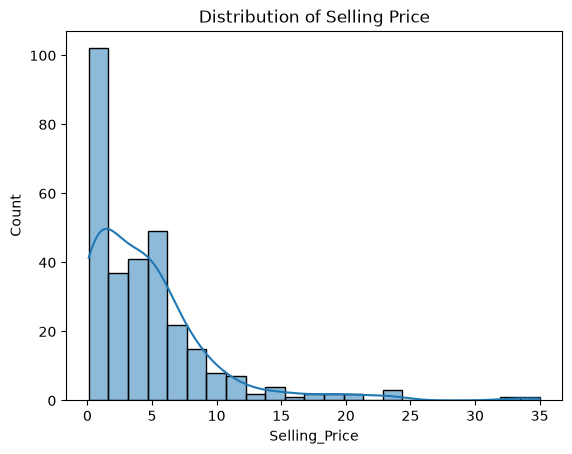

In [57]:
sns.histplot(df["Selling_Price"], kde=True)
plt.title("Distribution of Selling Price")
plt.show()

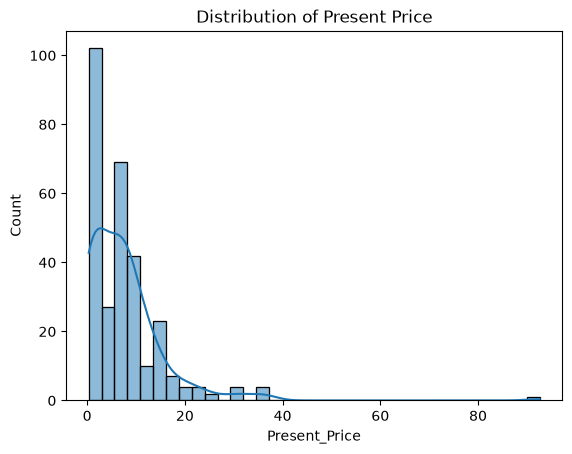

In [58]:
sns.histplot(df["Present_Price"], kde=True)
plt.title("Distribution of Present Price")
plt.show()

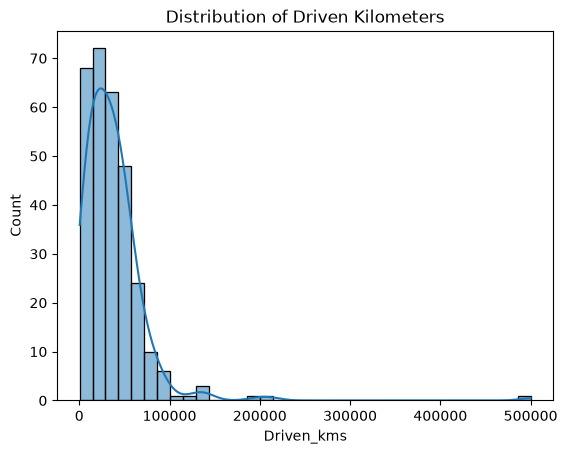

In [59]:
sns.histplot(df["Driven_kms"], kde=True)
plt.title("Distribution of Driven Kilometers")
plt.show()

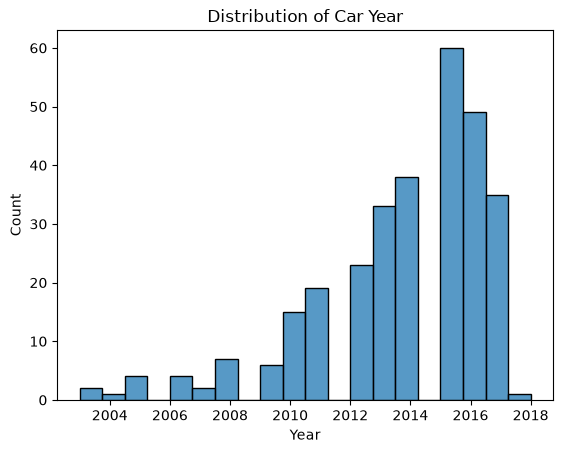

In [60]:
sns.histplot(df["Year"], bins=20)
plt.title("Distribution of Car Year")
plt.show()

Categorical Analysis 

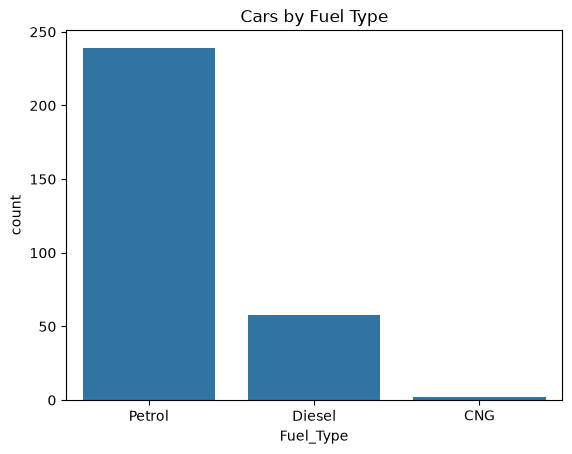

In [61]:
sns.countplot(data=df, x="Fuel_Type")
plt.title("Cars by Fuel Type")
plt.show()

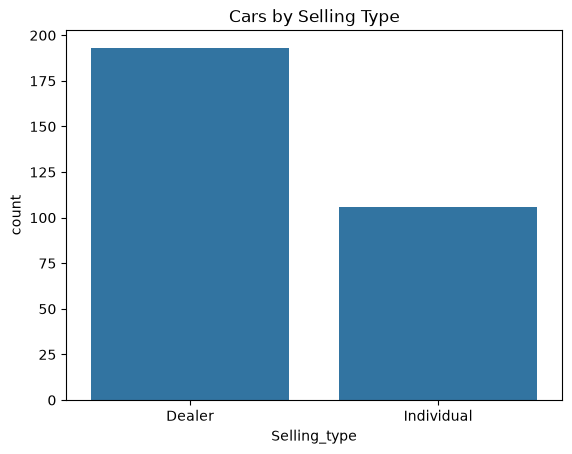

In [62]:
sns.countplot(data=df, x="Selling_type")
plt.title("Cars by Selling Type")
plt.show()

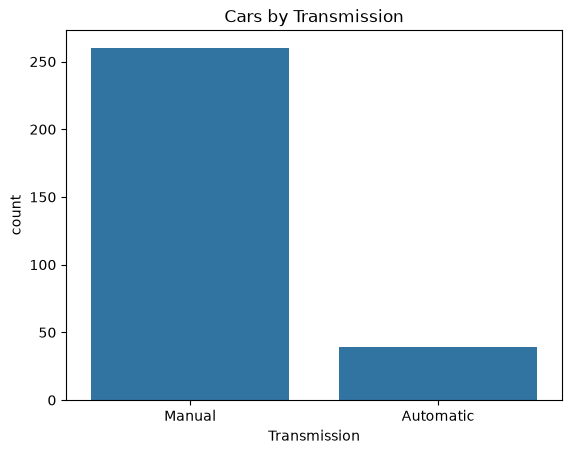

In [63]:
sns.countplot(data=df, x="Transmission")
plt.title("Cars by Transmission")
plt.show()

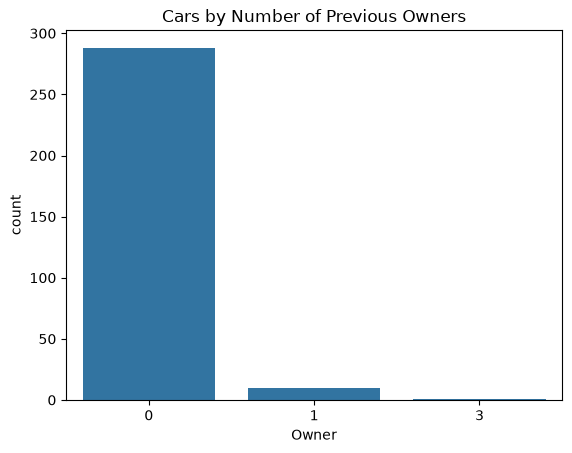

In [64]:
sns.countplot(data=df, x="Owner")
plt.title("Cars by Number of Previous Owners")
plt.show()

Scaling vs Selling Price

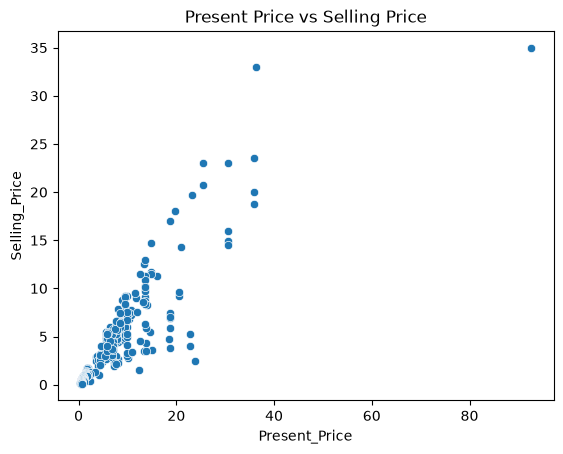

In [65]:
sns.scatterplot(data=df, x="Present_Price", y="Selling_Price")
plt.title("Present Price vs Selling Price")
plt.show()

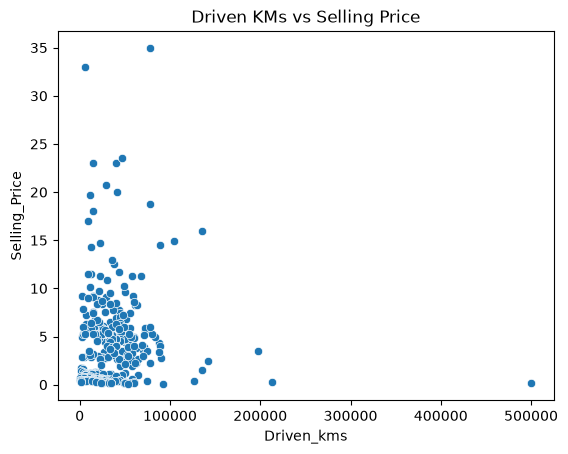

In [66]:
sns.scatterplot(data=df, x="Driven_kms", y="Selling_Price")
plt.title("Driven KMs vs Selling Price")
plt.show()

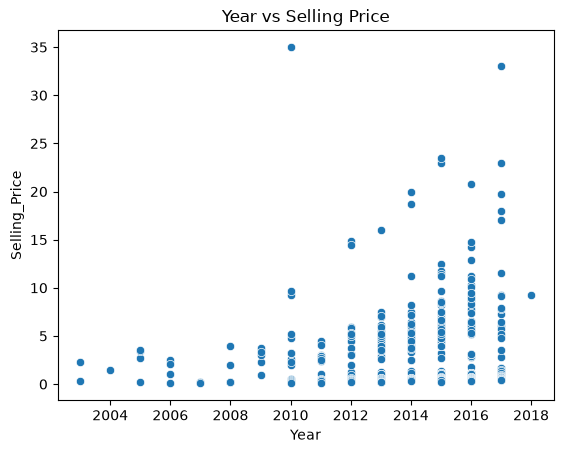

In [67]:
sns.scatterplot(data=df, x="Year", y="Selling_Price")
plt.title("Year vs Selling Price")
plt.show()

Categorical Features vs Selling Price

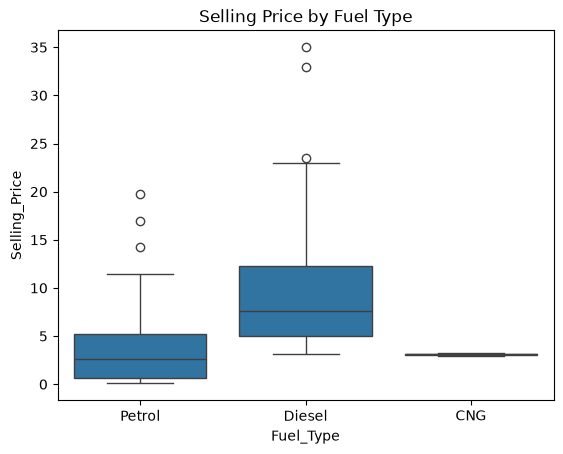

In [68]:
sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price")
plt.title("Selling Price by Fuel Type")
plt.show()

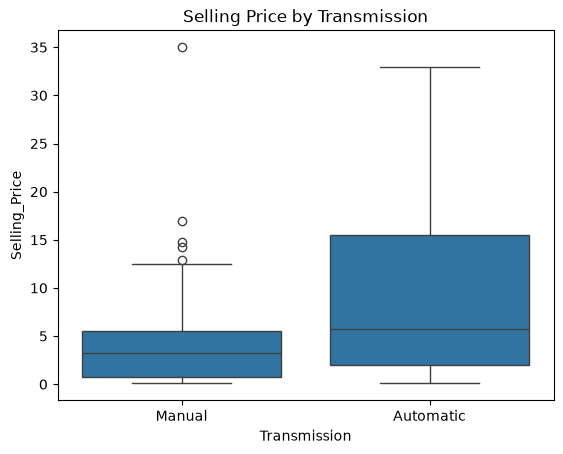

In [69]:
sns.boxplot(data=df, x="Transmission", y="Selling_Price")
plt.title("Selling Price by Transmission")
plt.show()

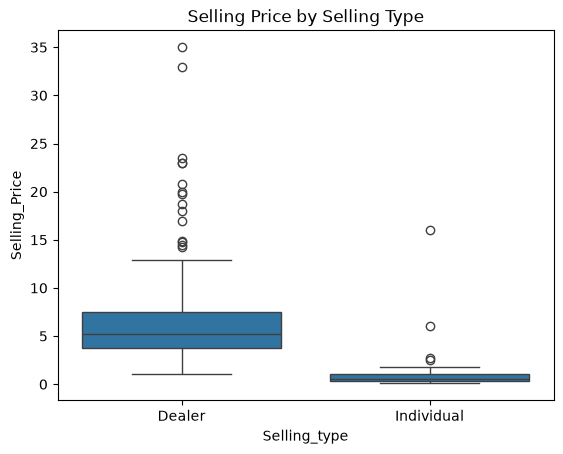

In [70]:
sns.boxplot(data=df, x="Selling_type", y="Selling_Price")
plt.title("Selling Price by Selling Type")
plt.show()

Correlation Analysis

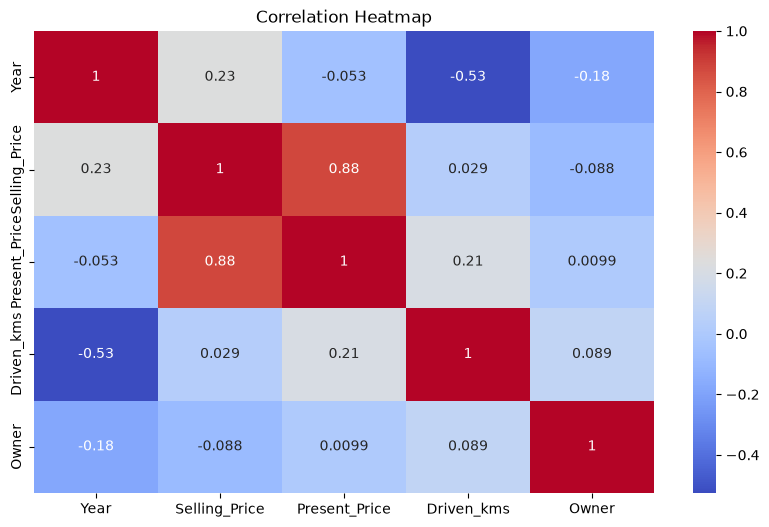

In [71]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [72]:
corr=numeric_df.corr()["Selling_Price"].abs().sort_values(ascending=False)
corr

Selling_Price    1.000000
Present_Price    0.876305
Year             0.234369
Owner            0.087880
Driven_kms       0.028566
Name: Selling_Price, dtype: float64

One-Hot Encoding or Label Encoding

In [81]:
df=pd.get_dummies(
    df,
    columns=["Fuel_Type", "Transmission", "Selling_type"],
    drop_first=True
)

Add data preprocessing and feature engineering

In [82]:
df["Car_Age"] = 2026 - df["Year"]

For finding the best model

In [83]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr=numeric_df.corr()["Selling_Price"].abs().sort_values(ascending=False)
corr

Selling_Price    1.000000
Present_Price    0.876305
Year             0.234369
Car_Age          0.234369
Owner            0.087880
Driven_kms       0.028566
Name: Selling_Price, dtype: float64

In [99]:
from sklearn.model_selection import train_test_split

X = df.drop(["Selling_Price","Car_Name","Driven_kms"], axis=1)
y = df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [100]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "KNN": KNeighborsRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(name)
    print("R² Score:", r2)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("-" * 30)

Linear Regression
R² Score: 0.7426567338342862
MSE: 6.632575480012068
RMSE: 2.575378706134705
MAE: 1.4845864224487857
------------------------------
Decision Tree
R² Score: 0.837031334749041
MSE: 4.20023414351852
RMSE: 2.049447277564983
MAE: 1.126138888888889
------------------------------
Random Forest
R² Score: 0.4954008578837348
MSE: 13.005166006870878
RMSE: 3.606267600563064
MAE: 1.5103628730158734
------------------------------
KNN
R² Score: 0.8470541796631961
MSE: 3.9419127333333353
RMSE: 1.9854250762326275
MAE: 0.9660333333333334
------------------------------


In [101]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = r2_score(y_test, y_pred)

print(results)

best_model = max(results, key=results.get)
print("Best Model:", best_model)

{'Linear Regression': 0.7426567338342862, 'Decision Tree': 0.837031334749041, 'Random Forest': 0.4954008578837348, 'KNN': 0.8470541796631961}
Best Model: KNN
